# Disproportionality Analysis — FEARS Pipeline Output
## PRR, ROR, and EBGM Signal Detection

Based on methodology from:
- **Evans et al. (2001)** — PRR
- **van Puijenbroek et al. (2002)** — ROR
- **DuMouchel (1999)** — MGPS / EBGM

**Data:** Final pipeline output (adult + pediatric cohorts)
**Subgroups:** Adult, Pediatric (overall), NICHD age bands

## 0. Setup

In [57]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from scipy.special import gammaln
from scipy.stats import gamma as gamma_dist
from IPython.display import display, Markdown
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (12, 5), "figure.dpi": 120, "font.size": 11})

## 1. Load Data

In [58]:
DATA_ROOT = Path("../data/output")

adult = pl.read_parquet(DATA_ROOT / "Adult" / "patient_report_reporter_drug_reaction_full_data.parquet")
pediatric = pl.read_parquet(DATA_ROOT / "Pediatric" / "patient_report_reporter_drug_reaction_full_data.parquet")

print(f"Adult:      {adult.height:>12,} rows | {adult['safetyreportid'].n_unique():>10,} unique reports")
print(f"Pediatric:  {pediatric.height:>12,} rows | {pediatric['safetyreportid'].n_unique():>10,} unique reports")
print(f"Total:      {adult.height + pediatric.height:>12,} rows")

Adult:        17,813,299 rows |  2,506,379 unique reports
Pediatric:       953,037 rows |    221,182 unique reports
Total:        18,766,336 rows


## 2. Core Functions

### 2.1 Precompute Pair Counts

สร้าง lookup table ครั้งเดียว แล้วใช้ O(1) ต่อ pair — เร็วกว่า filter ซ้ำหลายรอบ

In [59]:
def precompute_pair_counts(df: pl.DataFrame, drug_col: str, event_col: str) -> tuple:
    """Precompute all drug-event pair counts in one pass.

    Returns:
        pair_lookup: dict {(drug, event): count}
        drug_totals: dict {drug: total_events}
        event_totals: dict {event: total_drugs}
        N: total drug-event pairs
    """
    pairs = df.select(
        pl.col(drug_col).alias("drug"),
        pl.col(event_col).alias("event"),
    )

    N = pairs.height

    pair_counts = pairs.group_by(["drug", "event"]).agg(pl.len().alias("count"))
    drug_totals = dict(pairs.group_by("drug").agg(pl.len().alias("total")).iter_rows())
    event_totals = dict(pairs.group_by("event").agg(pl.len().alias("total")).iter_rows())

    pair_lookup = {}
    for row in pair_counts.iter_rows(named=True):
        pair_lookup[(row["drug"], row["event"])] = row["count"]

    return pair_lookup, drug_totals, event_totals, N


def get_2x2(pair_lookup, drug_totals, event_totals, N, target_drug, target_event):
    """Get 2x2 table values from precomputed counts (O(1) lookup).

    Returns: a, b, c, d
    """
    a = pair_lookup.get((target_drug, target_event), 0)
    b = drug_totals.get(target_drug, 0) - a      # drug + other events
    c = event_totals.get(target_event, 0) - a     # other drugs + this event
    d = N - a - b - c                             # other drugs + other events
    return a, b, c, d

print("Defined: precompute_pair_counts(), get_2x2()")

Defined: precompute_pair_counts(), get_2x2()


### 2.2 PRR (Proportional Reporting Ratio)

$$PRR = \frac{a / (a+b)}{c / (c+d)}$$

Signal: PRR >= 2 **AND** chi2 >= 4 **AND** a >= 3

In [60]:
def compute_prr(a, b, c, d):
    """PRR with 95% CI and chi-squared test."""
    if a == 0 or c == 0 or (a + b) == 0 or (c + d) == 0:
        return {"PRR": np.nan, "PRR_lower": np.nan, "PRR_upper": np.nan,
                "chi2": np.nan, "PRR_signal": False}

    prr = (a / (a + b)) / (c / (c + d))

    se = np.sqrt(1/a - 1/(a+b) + 1/c - 1/(c+d))
    ci_lo = np.exp(np.log(prr) - 1.96 * se)
    ci_hi = np.exp(np.log(prr) + 1.96 * se)

    table = np.array([[a, b], [c, d]])
    chi2_val, _, _, _ = chi2_contingency(table, correction=False)

    signal = (prr >= 2) and (chi2_val >= 4) and (a >= 3)

    return {
        "PRR": round(prr, 2),
        "PRR_lower": round(ci_lo, 2),
        "PRR_upper": round(ci_hi, 2),
        "chi2": round(chi2_val, 2),
        "PRR_signal": signal,
    }

print("Defined: compute_prr()")

Defined: compute_prr()


### 2.3 ROR (Reporting Odds Ratio)

$$ROR = \frac{a \times d}{b \times c}$$

Signal: ROR lower 95% CI > 1 **AND** a >= 3

In [61]:
def compute_ror(a, b, c, d):
    """ROR with 95% CI."""
    if a == 0 or b == 0 or c == 0 or d == 0:
        return {"ROR": np.nan, "ROR_lower": np.nan, "ROR_upper": np.nan,
                "ROR_signal": False}

    ror = (a * d) / (b * c)

    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    ci_lo = np.exp(np.log(ror) - 1.96 * se)
    ci_hi = np.exp(np.log(ror) + 1.96 * se)

    signal = (ci_lo > 1) and (a >= 3)

    return {
        "ROR": round(ror, 2),
        "ROR_lower": round(ci_lo, 2),
        "ROR_upper": round(ci_hi, 2),
        "ROR_signal": signal,
    }

print("Defined: compute_ror()")

Defined: compute_ror()


### 2.4 EBGM (Empirical Bayesian Geometric Mean)

Bayesian shrinkage — ลด false positive จาก drug-event pairs ที่มี report น้อย

$$EBGM = Q \cdot \frac{\alpha_1 + a}{\beta_1 + E} + (1-Q) \cdot \frac{\alpha_2 + a}{\beta_2 + E}$$

Signal: EBGM05 (5th percentile) >= 2

In [62]:
def compute_ebgm(a, E):
    """EBGM with fixed prior parameters (DuMouchel 1999)."""
    # Prior parameters (from openEBGM / PhViD literature)
    alpha_mix = 0.2
    a1, b1 = 0.2, 0.1   # background component
    a2, b2 = 2.0, 4.0   # signal component

    if E == 0 or a == 0:
        return {"EBGM": np.nan, "EBGM05": np.nan, "EBGM95": np.nan,
                "EBGM_signal": False}

    # Posterior mixing weight (log-space for stability)
    log_w1 = (np.log(alpha_mix) + a1 * np.log(b1)
              - (a1 + a) * np.log(b1 + E)
              + gammaln(a1 + a) - gammaln(a1))
    log_w2 = (np.log(1 - alpha_mix) + a2 * np.log(b2)
              - (a2 + a) * np.log(b2 + E)
              + gammaln(a2 + a) - gammaln(a2))

    log_max = max(log_w1, log_w2)
    Q = np.exp(log_w1 - log_max) / (np.exp(log_w1 - log_max) + np.exp(log_w2 - log_max))

    # Posterior mean
    ebgm = Q * (a1 + a) / (b1 + E) + (1 - Q) * (a2 + a) / (b2 + E)

    # 5th and 95th percentiles
    ebgm05 = Q * gamma_dist.ppf(0.05, a1 + a, scale=1/(b1 + E)) +              (1 - Q) * gamma_dist.ppf(0.05, a2 + a, scale=1/(b2 + E))
    ebgm95 = Q * gamma_dist.ppf(0.95, a1 + a, scale=1/(b1 + E)) +              (1 - Q) * gamma_dist.ppf(0.95, a2 + a, scale=1/(b2 + E))

    return {
        "EBGM": round(ebgm, 2),
        "EBGM05": round(ebgm05, 2),
        "EBGM95": round(ebgm95, 2),
        "EBGM_signal": ebgm05 >= 2,
    }

print("Defined: compute_ebgm()")

Defined: compute_ebgm()


### 2.5 Batch Computation

รวม PRR + ROR + EBGM เข้าด้วยกัน คำนวณทีเดียวหลาย pairs

In [63]:
def compute_signals_batch(df, drug_col, event_col, pairs, label=""):
    """Compute PRR, ROR, EBGM for a list of (drug, event) pairs.

    Precomputes pair counts once, then O(1) per pair.
    """
    pair_lookup, drug_totals, event_totals, N = precompute_pair_counts(df, drug_col, event_col)

    results = []
    for drug, event in pairs:
        a, b, c, d = get_2x2(pair_lookup, drug_totals, event_totals, N, drug, event)
        E = ((a + b) * (a + c)) / N if N > 0 else 0

        prr = compute_prr(a, b, c, d)
        ror = compute_ror(a, b, c, d)
        ebgm = compute_ebgm(a, E)

        results.append({
            "drug": drug, "event": event,
            "N_total": N, "a (cases)": a, "E (expected)": round(E, 2),
            **prr, **ror, **ebgm,
        })

    return pl.DataFrame(results).cast({
        "PRR_signal": pl.Boolean,
        "ROR_signal": pl.Boolean,
        "EBGM_signal": pl.Boolean,
    }, strict=False)


def _fmt(val, lo, hi):
    """Format value with 95% CI: '12.34 (10.00, 14.50)'"""
    if val is None or np.isnan(val):
        return "—"
    if lo is None or np.isnan(lo):
        return f"{val:.2f}"
    return f"{val:.2f} ({lo:.2f}, {hi:.2f})"


def _fmt_ebgm(val, lo):
    """Format EBGM with lower bound: '12.34 (10.00)'"""
    if val is None or np.isnan(val):
        return "—"
    if lo is None or np.isnan(lo):
        return f"{val:.2f}"
    return f"{val:.2f} ({lo:.2f})"


def _signal_icon(prr_sig, ror_sig, ebgm_sig):
    """Show signal status per method: 1 = signal, 0 = non-signal."""
    p = 1 if prr_sig else 0
    r = 1 if ror_sig else 0
    e = 1 if ebgm_sig else 0
    return f"{p}/{r}/{e}"


def format_signal_table(signals_df):
    """Format signals into compact publication-style table.

    Signal column shows PRR/ROR/EBGM as +/- (e.g. +/+/+ = all agree).
    """
    rows = []
    for r in signals_df.iter_rows(named=True):
        rows.append({
            "Drug": r["drug"],
            "Event": r["event"],
            "Cases (a)": r["a (cases)"],
            "Expected (E)": round(r["E (expected)"], 2),
            "ROR (95% CI)": _fmt(r["ROR"], r["ROR_lower"], r["ROR_upper"]),
            "PRR (95% CI)": _fmt(r["PRR"], r["PRR_lower"], r["PRR_upper"]),
            "chi2": round(r["chi2"], 2) if r["chi2"] is not None and not np.isnan(r["chi2"]) else "—",
            "EBGM (EBGM05)": _fmt_ebgm(r["EBGM"], r["EBGM05"]),
            "Signal (P/R/E)": _signal_icon(r["PRR_signal"], r["ROR_signal"], r["EBGM_signal"]),
        })
    return pl.DataFrame(rows).sort("Cases (a)", descending=True)


def format_signal_table_by_ror(signals_df):
    """Format signals sorted by ROR descending (top signals first)."""
    rows = []
    for r in signals_df.sort("ROR", descending=True, nulls_last=True).iter_rows(named=True):
        rows.append({
            "Drug": r["drug"],
            "Event": r["event"],
            "Cases (a)": r["a (cases)"],
            "Expected (E)": round(r["E (expected)"], 2),
            "ROR (95% CI)": _fmt(r["ROR"], r["ROR_lower"], r["ROR_upper"]),
            "PRR (95% CI)": _fmt(r["PRR"], r["PRR_lower"], r["PRR_upper"]),
            "chi2": round(r["chi2"], 2) if r["chi2"] is not None and not np.isnan(r["chi2"]) else "—",
            "EBGM (EBGM05)": _fmt_ebgm(r["EBGM"], r["EBGM05"]),
            "Signal (P/R/E)": _signal_icon(r["PRR_signal"], r["ROR_signal"], r["EBGM_signal"]),
        })
    return pl.DataFrame(rows)

print("Defined: compute_signals_batch(), _fmt(), _fmt_ebgm(), _signal_icon(), format_signal_table()")

Defined: compute_signals_batch(), _fmt(), _fmt_ebgm(), _signal_icon(), format_signal_table()


## 3. Compute All Drug-Event Pairs

Compute PRR, ROR, EBGM for **every unique (drug, event) pair** in each cohort, then show Top 50 sorted by ROR.

In [64]:
def get_all_drug_event_pairs(df):
    """Get ALL unique (drug, event) pairs in the dataset."""
    pairs = (
        df.select("medicinal_product", "reaction_meddrapt")
        .unique()
        .filter(
            pl.col("medicinal_product").is_not_null()
            & pl.col("reaction_meddrapt").is_not_null()
        )
    )
    return list(zip(
        pairs["medicinal_product"].to_list(),
        pairs["reaction_meddrapt"].to_list(),
    ))

adult_pairs = get_all_drug_event_pairs(adult)
pediatric_pairs = get_all_drug_event_pairs(pediatric)

print(f"Adult pairs (all):     {len(adult_pairs):,}")
print(f"Pediatric pairs (all): {len(pediatric_pairs):,}")

Adult pairs:     150
Pediatric pairs: 150

Example: [('ENBREL', 'Arthralgia'), ('ENBREL', 'Pain'), ('ENBREL', 'Fatigue')]


## 4. Top 50 Signals (by ROR)

### 4.1 Adult Cohort

In [65]:
print("Computing Adult signals (all pairs)...")
adult_signals = compute_signals_batch(adult, "medicinal_product", "reaction_meddrapt", adult_pairs, label="Adult")
print(f"Done: {adult_signals.height:,} pairs computed")

display(Markdown("**Top 50 Adult Signals (sorted by ROR, descending):**"))
display(format_signal_table_by_ror(adult_signals).head(50))

Computing Adult signals...
Done: 150 pairs


**Top 50 Adult Drug-Event Signals (ranked by signal strength):**

Drug,Event,Cases (a),Expected (E),ROR (95% CI),PRR (95% CI),chi2,EBGM (EBGM05),Signal (P/R/E)
str,str,i64,f64,str,str,f64,str,str
"""DUPIXENT""","""Pruritus""",24341,2293.99,"""13.48 (13.29, 13.67)""","""11.70 (11.55, 11.84)""",216852.89,"""10.61 (10.50)""","""1/1/1"""
"""ENBREL""","""Arthralgia""",16282,5331.95,"""3.29 (3.24, 3.34)""","""3.16 (3.12, 3.21)""",23287.11,"""3.05 (3.01)""","""1/1/1"""
"""ENBREL""","""Pain""",16158,6973.31,"""2.45 (2.41, 2.49)""","""2.37 (2.33, 2.41)""",12598.29,"""2.32 (2.29)""","""1/1/1"""
"""DUPIXENT""","""Rash""",13420,3487.73,"""4.21 (4.13, 4.29)""","""3.96 (3.89, 4.02)""",29154.13,"""3.85 (3.79)""","""1/1/1"""
"""OTEZLA""","""Diarrhoea""",11840,2490.94,"""5.33 (5.22, 5.43)""","""4.87 (4.79, 4.95)""",36113.54,"""4.75 (4.68)""","""1/1/1"""
…,…,…,…,…,…,…,…,…
"""CIMZIA""","""Rash""",4099,2521.12,"""1.65 (1.60, 1.71)""","""1.63 (1.58, 1.68)""",1015.17,"""1.62 (1.58)""","""0/1/0"""
"""XELJANZ XR""","""Pain""",4095,1048.05,"""4.23 (4.10, 4.37)""","""3.94 (3.82, 4.05)""",9094.18,"""3.91 (3.81)""","""1/1/1"""
"""SIMPONI""","""Rash""",3892,2509.74,"""1.57 (1.53, 1.63)""","""1.56 (1.51, 1.61)""",782.57,"""1.55 (1.51)""","""0/1/0"""


### 4.2 Pediatric Cohort — Top 50 Signals

In [66]:
print("Computing Pediatric signals (all pairs)...")
ped_signals = compute_signals_batch(pediatric, "medicinal_product", "reaction_meddrapt", pediatric_pairs, label="Pediatric")
print(f"Done: {ped_signals.height:,} pairs computed")

display(Markdown("**Top 50 Pediatric Signals (sorted by ROR, descending):**"))
display(format_signal_table_by_ror(ped_signals).head(50))

Computing Pediatric signals...
Done: 150 pairs


**Top 50 Pediatric Drug-Event Signals (ranked by signal strength):**

Drug,Event,Cases (a),Expected (E),ROR (95% CI),PRR (95% CI),chi2,EBGM (EBGM05),Signal (P/R/E)
str,str,i64,f64,str,str,f64,str,str
"""DUPIXENT""","""Pruritus""",7205,572.04,"""31.00 (29.92, 32.12)""","""25.59 (24.79, 26.43)""",81445.46,"""12.59 (12.35)""","""1/1/1"""
"""DUPIXENT""","""Eczema""",5150,279.09,"""89.76 (84.67, 95.17)""","""78.33 (74.02, 82.90)""",89356.93,"""18.45 (18.03)""","""1/1/1"""
"""DUPIXENT""","""Rash""",4499,673.46,"""9.89 (9.54, 10.26)""","""8.89 (8.60, 9.19)""",23071.06,"""6.68 (6.52)""","""1/1/1"""
"""ACETAMINOPHEN""","""Vomiting""",921,217.02,"""4.88 (4.55, 5.24)""","""4.34 (4.09, 4.61)""",2377.73,"""4.24 (4.02)""","""1/1/1"""
"""REMICADE""","""Haematochezia""",737,24.45,"""44.12 (40.45, 48.12)""","""40.20 (37.08, 43.59)""",21009.17,"""30.03 (28.23)""","""1/1/1"""
…,…,…,…,…,…,…,…,…
"""ETOPOSIDE.""","""Neutropenia""",276,94.82,"""3.05 (2.70, 3.45)""","""2.94 (2.62, 3.30)""",354.54,"""2.91 (2.62)""","""1/1/1"""
"""PREDNISONE.""","""Pyrexia""",271,212.74,"""1.29 (1.14, 1.46)""","""1.28 (1.14, 1.43)""",16.64,"""1.26 (1.14)""","""0/1/0"""
"""CYTARABINE""","""Neutropenia""",268,98.88,"""2.83 (2.50, 3.20)""","""2.74 (2.43, 3.08)""",296.26,"""2.70 (2.44)""","""1/1/1"""


## 5. Subgroup Analysis — NICHD Age Bands

คำนวณ signals ใหม่ภายในแต่ละ age band ของ pediatric:
- infancy (0-11 months)
- toddler (1 year)
- early_childhood (2-5 years)
- middle_childhood (6-11 years)
- early_adolescence (12-17 years)
- late_adolescence (18-21 years)

In [67]:
nichd_bands = ["infancy", "toddler", "early_childhood", "middle_childhood",
               "early_adolescence", "late_adolescence"]

# Use top 30 pediatric pairs by ROR for subgroup analysis
top_ped_by_ror = ped_signals.sort('ROR', descending=True, nulls_last=True).head(30)
top_ped_pairs = list(zip(top_ped_by_ror['drug'].to_list(), top_ped_by_ror['event'].to_list()))
subgroup_df = pl.DataFrame()

if "nichd" in pediatric.columns:
    subgroup_dfs = []
    for band in nichd_bands:
        sub_df = pediatric.filter(pl.col("nichd") == band)
        if sub_df.height < 10:
            print(f"  {band}: {sub_df.height} rows — skipped")
            continue

        print(f"  {band}: {sub_df.height:,} rows")
        band_signals = compute_signals_batch(
            sub_df, "medicinal_product", "reaction_meddrapt", top_ped_pairs
        )
        band_signals = band_signals.with_columns(
            pl.lit(band).alias("nichd_band"),
            pl.lit(sub_df.height).alias("subgroup_n"),
        )
        subgroup_dfs.append(band_signals)

    if subgroup_dfs:
        subgroup_df = pl.concat(subgroup_dfs, how="vertical_relaxed")
        print(f"\nTotal: {subgroup_df.height} rows across {len(subgroup_dfs)} bands")
else:
    print("nichd column not available")

  infancy: 64,675 rows
  toddler: 32,239 rows
  early_childhood: 136,785 rows
  middle_childhood: 173,351 rows
  early_adolescence: 317,459 rows
  late_adolescence: 228,528 rows

Total: 90 rows across 6 bands


In [68]:
# Display subgroup results (a >= 3 only) — compact format
if subgroup_df.height > 0:
    sub_rows = []
    for r in subgroup_df.filter(pl.col("a (cases)") >= 3).iter_rows(named=True):
        sub_rows.append({
            "NICHD Band": r["nichd_band"],
            "N (subgroup)": r["subgroup_n"],
            "Drug": r["drug"],
            "Event": r["event"],
            "Cases (a)": r["a (cases)"],
            "ROR (95% CI)": _fmt(r["ROR"], r["ROR_lower"], r["ROR_upper"]),
            "PRR (95% CI)": _fmt(r["PRR"], r["PRR_lower"], r["PRR_upper"]),
            "chi2": round(r["chi2"], 2) if r.get("chi2") is not None and not np.isnan(r.get("chi2", float("nan"))) else "—",
            "EBGM (EBGM05)": _fmt_ebgm(r["EBGM"], r["EBGM05"]),
            "Signal (P/R/E)": _signal_icon(r["PRR_signal"], r["ROR_signal"], r["EBGM_signal"]),
        })
    sub_table = pl.DataFrame(sub_rows).sort(["Drug", "Event", "NICHD Band"])
    display(Markdown(f"**Pediatric Subgroup Signals (a >= 3): {sub_table.height} rows**"))
    display(sub_table)
else:
    print("No subgroup data")

**Pediatric Subgroup Signals (a >= 3): 85 rows**

NICHD Band,N (subgroup),Drug,Event,Cases (a),ROR (95% CI),PRR (95% CI),chi2,EBGM (EBGM05),Signal (P/R/E)
str,i64,str,str,i64,str,str,f64,str,str
"""early_adolescence""",317459,"""DUPIXENT""","""Eczema""",1493,"""119.01 (105.56, 134.18)""","""105.34 (93.69, 118.43)""",28440.66,"""20.10 (19.25)""","""1/1/1"""
"""early_childhood""",136785,"""DUPIXENT""","""Eczema""",1184,"""137.00 (116.96, 160.47)""","""115.01 (98.57, 134.19)""",18008.58,"""16.17 (15.41)""","""1/1/1"""
"""infancy""",64675,"""DUPIXENT""","""Eczema""",52,"""174.54 (119.78, 254.33)""","""146.16 (104.11, 205.20)""",4361.38,"""73.55 (57.65)""","""1/1/1"""
"""late_adolescence""",228528,"""DUPIXENT""","""Eczema""",1012,"""57.31 (51.47, 63.82)""","""50.45 (45.53, 55.90)""",17015.51,"""18.01 (17.09)""","""1/1/1"""
"""middle_childhood""",173351,"""DUPIXENT""","""Eczema""",1163,"""67.66 (59.76, 76.60)""","""59.64 (52.87, 67.28)""",14950.16,"""13.95 (13.28)""","""1/1/1"""
…,…,…,…,…,…,…,…,…,…
"""early_childhood""",136785,"""VINCRISTINE""","""Sepsis""",98,"""3.37 (2.74, 4.15)""","""3.27 (2.68, 3.99)""",148.52,"""3.14 (2.64)""","""1/1/1"""
"""infancy""",64675,"""VINCRISTINE""","""Sepsis""",28,"""4.51 (3.06, 6.65)""","""4.27 (2.97, 6.13)""",69.32,"""4.14 (2.94)""","""1/1/1"""
"""late_adolescence""",228528,"""VINCRISTINE""","""Sepsis""",52,"""4.16 (3.14, 5.51)""","""4.04 (3.08, 5.29)""",117.28,"""3.95 (3.10)""","""1/1/1"""


## 6. Cross-Cohort Comparison

เปรียบเทียบ drug-event pairs **เดียวกัน** ระหว่าง Adult, Pediatric, และทุก NICHD subgroup

In [69]:
# Find common drug-event pairs in both cohorts
common_drugs = set(adult["medicinal_product"].unique().to_list()) & set(pediatric["medicinal_product"].unique().to_list())
common_events = set(adult["reaction_meddrapt"].unique().to_list()) & set(pediatric["reaction_meddrapt"].unique().to_list())

common_pairs = [
    (drug, event) for drug, event in adult_pairs
    if drug in common_drugs and event in common_events
][:20]

print(f"Common pairs for comparison: {len(common_pairs)}")

Common pairs for comparison: 20


In [70]:
# Compute for Adult
print("  Adult...")
cross_adult = compute_signals_batch(
    adult, "medicinal_product", "reaction_meddrapt", common_pairs
).with_columns(pl.lit("Adult").alias("cohort"))

# Compute for Pediatric overall
print("  Pediatric...")
cross_ped = compute_signals_batch(
    pediatric, "medicinal_product", "reaction_meddrapt", common_pairs
).with_columns(pl.lit("Pediatric").alias("cohort"))

cross_parts = [cross_adult, cross_ped]

# Compute for each NICHD subgroup
if "nichd" in pediatric.columns:
    for band in nichd_bands:
        sub_df = pediatric.filter(pl.col("nichd") == band)
        if sub_df.height >= 10:
            print(f"  Ped-{band}...")
            cross_sub = compute_signals_batch(
                sub_df, "medicinal_product", "reaction_meddrapt", common_pairs
            ).with_columns(pl.lit(f"Ped-{band}").alias("cohort"))
            cross_parts.append(cross_sub)

cross_df = pl.concat(cross_parts, how="vertical_relaxed")
print(f"\nTotal: {cross_df.height} rows")

  Adult...
  Pediatric...
  Ped-infancy...
  Ped-toddler...
  Ped-early_childhood...
  Ped-middle_childhood...
  Ped-early_adolescence...
  Ped-late_adolescence...

Total: 160 rows


In [71]:
# Display cross-cohort comparison — compact format
display(Markdown("### Cross-Cohort Signal Comparison"))

cross_rows = []
for r in cross_df.iter_rows(named=True):
    cross_rows.append({
        "Cohort": r["cohort"],
        "Drug": r["drug"],
        "Event": r["event"],
        "Cases (a)": r["a (cases)"],
        "Expected (E)": round(r["E (expected)"], 2),
        "ROR (95% CI)": _fmt(r["ROR"], r["ROR_lower"], r["ROR_upper"]),
        "PRR (95% CI)": _fmt(r["PRR"], r["PRR_lower"], r["PRR_upper"]),
        "chi2": round(r["chi2"], 2) if r.get("chi2") is not None and not np.isnan(r.get("chi2", float("nan"))) else "—",
        "EBGM (EBGM05)": _fmt_ebgm(r["EBGM"], r["EBGM05"]),
        "Signal (P/R/E)": _signal_icon(r["PRR_signal"], r["ROR_signal"], r["EBGM_signal"]),
    })
cross_table = pl.DataFrame(cross_rows).sort(["Drug", "Event", "Cohort"])
display(cross_table)

### Cross-Cohort Signal Comparison

Cohort,Drug,Event,Cases (a),Expected (E),ROR (95% CI),PRR (95% CI),chi2,EBGM (EBGM05),Signal (P/R/E)
str,str,str,i64,f64,str,str,str,str,str
"""Adult""","""DUPIXENT""","""Eczema""",9731,286.75,"""52.76 (51.48, 54.08)""","""49.81 (48.64, 51.01)""","""314592.08""","""33.92 (33.36)""","""1/1/1"""
"""Ped-early_adolescence""","""DUPIXENT""","""Eczema""",1493,74.2,"""119.01 (105.56, 134.18)""","""105.34 (93.69, 118.43)""","""28440.66""","""20.10 (19.25)""","""1/1/1"""
"""Ped-early_childhood""","""DUPIXENT""","""Eczema""",1184,73.13,"""137.00 (116.96, 160.47)""","""115.01 (98.57, 134.19)""","""18008.58""","""16.17 (15.41)""","""1/1/1"""
"""Ped-infancy""","""DUPIXENT""","""Eczema""",52,0.61,"""174.54 (119.78, 254.33)""","""146.16 (104.11, 205.20)""","""4361.38""","""73.55 (57.65)""","""1/1/1"""
"""Ped-late_adolescence""","""DUPIXENT""","""Eczema""",1012,56.1,"""57.31 (51.47, 63.82)""","""50.45 (45.53, 55.90)""","""17015.51""","""18.01 (17.09)""","""1/1/1"""
…,…,…,…,…,…,…,…,…,…
"""Ped-infancy""","""RITUXIMAB""","""Pain""",1,0.55,"""1.82 (0.25, 13.08)""","""1.82 (0.26, 12.85)""","""0.37""","""0.82 (0.17)""","""0/0/0"""
"""Ped-late_adolescence""","""RITUXIMAB""","""Pain""",7,9.92,"""0.70 (0.33, 1.48)""","""0.71 (0.34, 1.48)""","""0.87""","""0.65 (0.34)""","""0/0/0"""
"""Ped-middle_childhood""","""RITUXIMAB""","""Pain""",5,9.19,"""0.54 (0.22, 1.30)""","""0.54 (0.23, 1.30)""","""1.94""","""0.53 (0.25)""","""0/0/0"""


## 7. Visualization — PRR Comparison

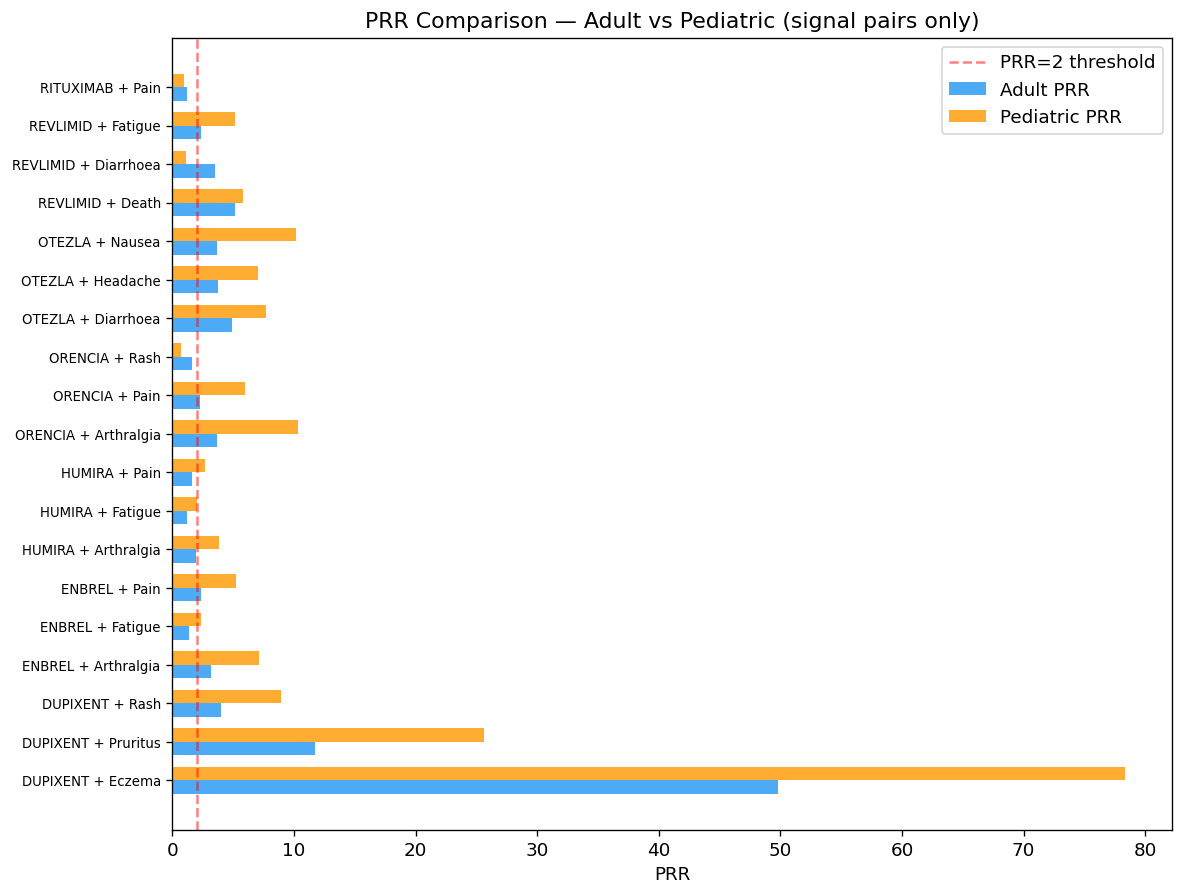

In [72]:
if cross_df.height > 0:
    cross_with_label = cross_df.with_columns(
        (pl.col("drug") + " + " + pl.col("event")).alias("pair")
    )

    # Filter to signal pairs only
    has_signal = (
        cross_with_label
        .group_by("pair")
        .agg(pl.col("PRR_signal").any().alias("any_signal"))
        .filter(pl.col("any_signal"))["pair"].to_list()
    )

    signal_pairs = cross_with_label.filter(pl.col("pair").is_in(has_signal))

    if signal_pairs.height > 0:
        pivot_data = (
            signal_pairs
            .filter(pl.col("cohort").is_in(["Adult", "Pediatric"]))
            .select(["pair", "cohort", "PRR"])
            .pivot(on="cohort", index="pair", values="PRR")
            .sort("pair")
        )

        if pivot_data.height > 0:
            fig, ax = plt.subplots(figsize=(10, max(4, pivot_data.height * 0.4)))
            pairs_list = pivot_data["pair"].to_list()
            adult_prr = [v if v is not None else 0 for v in pivot_data.get_column("Adult").to_list()]
            ped_prr = [v if v is not None else 0 for v in pivot_data.get_column("Pediatric").to_list()]

            y = np.arange(len(pairs_list))
            h = 0.35
            ax.barh(y - h/2, adult_prr, h, label="Adult PRR", color="#2196F3", alpha=0.8)
            ax.barh(y + h/2, ped_prr, h, label="Pediatric PRR", color="#FF9800", alpha=0.8)
            ax.axvline(x=2, color="red", linestyle="--", alpha=0.5, label="PRR=2 threshold")
            ax.set_yticks(y)
            ax.set_yticklabels(pairs_list, fontsize=8)
            ax.set_xlabel("PRR")
            ax.set_title("PRR Comparison — Adult vs Pediatric (signal pairs only)")
            ax.legend()
            plt.tight_layout()
            plt.savefig("../notebook/prr_comparison.png", dpi=150, bbox_inches="tight")
            plt.show()

## 8. Export Results

In [73]:
output_dir = Path("../data/notebook/output/analysis")
output_dir.mkdir(parents=True, exist_ok=True)

adult_signals.write_parquet(output_dir / "adult_disproportionality_signals.parquet")
ped_signals.write_parquet(output_dir / "pediatric_disproportionality_signals.parquet")
cross_df.write_parquet(output_dir / "cross_cohort_comparison.parquet")
if subgroup_df.height > 0:
    subgroup_df.write_parquet(output_dir / "pediatric_nichd_subgroup_signals.parquet")

print(f"Saved to {output_dir}/")
print(f"  adult_disproportionality_signals.parquet     ({adult_signals.height} rows)")
print(f"  pediatric_disproportionality_signals.parquet  ({ped_signals.height} rows)")
print(f"  cross_cohort_comparison.parquet               ({cross_df.height} rows)")
if subgroup_df.height > 0:
    print(f"  pediatric_nichd_subgroup_signals.parquet      ({subgroup_df.height} rows)")

Saved to ../data/notebook/output/analysis/
  adult_disproportionality_signals.parquet     (150 rows)
  pediatric_disproportionality_signals.parquet  (150 rows)
  cross_cohort_comparison.parquet               (160 rows)
  pediatric_nichd_subgroup_signals.parquet      (90 rows)


---

## Methodology Notes

| Metric | Formula | Signal Threshold | Reference |
|--------|---------|-----------------|-----------|
| **PRR** | (a/(a+b)) / (c/(c+d)) | PRR >= 2, chi2 >= 4, a >= 3 | Evans et al., 2001 |
| **ROR** | (a*d) / (b*c) | ROR lower 95% CI > 1, a >= 3 | van Puijenbroek et al., 2002 |
| **EBGM** | Bayesian posterior mean (MGPS) | EBGM05 >= 2 | DuMouchel, 1999 |

**Subgroup analysis:** 2x2 table reconstructed within each NICHD age band independently.

**EBGM prior:** Fixed prior parameters from literature. For production, fit via EM on all drug-event pairs.